In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load and inspect data

In [3]:
df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.isna().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

1. we have multiple columns with empty values
2. It could mean that the house doesn't have a pool for example and hence the values was kept as empty.
3. Also, we can drop id as it's not required for our training

In [7]:
df.drop(columns=['Id'], inplace=True)

In [8]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 2. Data Cleaning

1. PoolQC: NA = "No Pool"
2. Alley: NA = "No alley access"
3. Fence: NA = "No Fence"
4. FireplaceQu: NA = "No Fireplace"
5. GarageType, GarageFinish, GarageQual, GarageCond: NA = "No Garage"
6. BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2: NA = "No Basement"
7. MasVnrType: NA likely means "None" (no masonry veneer)

In [9]:
# categorical columns to fix with None

columns_to_fix = ['PoolQC', 'Alley', 'Fence', 
                  'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 
                  'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
                  'BsmtFinType1', 'BsmtFinType2', 'MasVnrType', 'MiscFeature']

df[columns_to_fix]= df[columns_to_fix].fillna(value='None')

In [10]:
df.isna().sum().sort_values(ascending=False).head(20)

LotFrontage     259
GarageYrBlt      81
MasVnrArea        8
Electrical        1
Street            0
MSSubClass        0
MSZoning          0
LotArea           0
Utilities         0
LotConfig         0
LandSlope         0
Neighborhood      0
Condition1        0
Alley             0
LotShape          0
LandContour       0
HouseStyle        0
BldgType          0
Condition2        0
YearBuilt         0
dtype: int64

In [11]:
df['GarageArea'].value_counts()

GarageArea
0       81
440     49
576     47
240     38
484     34
        ..
370      1
1069     1
372      1
923      1
192      1
Name: count, Length: 441, dtype: int64

In [12]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [13]:
df.isna().sum().sort_values(ascending=False)

LotFrontage      259
GarageYrBlt       81
Electrical         1
MSSubClass         0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [14]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

GarageYrBlt — Missing Value Handling

81 missing values, all corresponding to houses with no garage (GarageType == "None"). Filled with each row's YearBuilt instead of 0, since 0 would be a nonsensical "year" and skew a linear model. To avoid the model misreading this placeholder as a real garage year, added a separate HasGarage flag (1/0) in feature engineering so "no garage" is captured explicitly.

In [15]:
df.isna().sum().sort_values(ascending=False).head()

LotFrontage    259
Electrical       1
MSZoning         0
MSSubClass       0
Street           0
dtype: int64

now we have two columns with missing values

1. Electrical - just one row we can fill it with mode
2. LotFrontage - largest missing column - Fill it with the median LotFrontage grouped by Neighborhood

In [16]:

df['Electrical'].mode()[0]

'SBrkr'

In [17]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [18]:
df['LotFrontage'] = df['LotFrontage'].fillna(
    df.groupby('Neighborhood')['LotFrontage'].transform('median')
)

In [19]:
df.isna().sum().sort_values(ascending=False)

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

# 3. Univariate Analysis

## Step 1: Skewness and Kurtosis

In [20]:
print("Skewness:", df['SalePrice'].skew())
print("Kurtosis:", df['SalePrice'].kurt())

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


SalePrice skewness ≈ 1.88, kurtosis ≈ 6.5 — confirms strong right-skew with heavy tails, meaning a small number of very expensive houses are pulling the distribution away from normal.

## Step 2: Mean vs Median

In [21]:
print("Mean:", df['SalePrice'].mean())
print("Median:", df['SalePrice'].median())

Mean: 180921.19589041095
Median: 163000.0


Mean (~180k) is higher than median (~163k) — the gap confirms the distribution is pulled rightward by expensive homes, consistent with the skewness value above.

## Step 3: Histogram — raw vs log-transformed

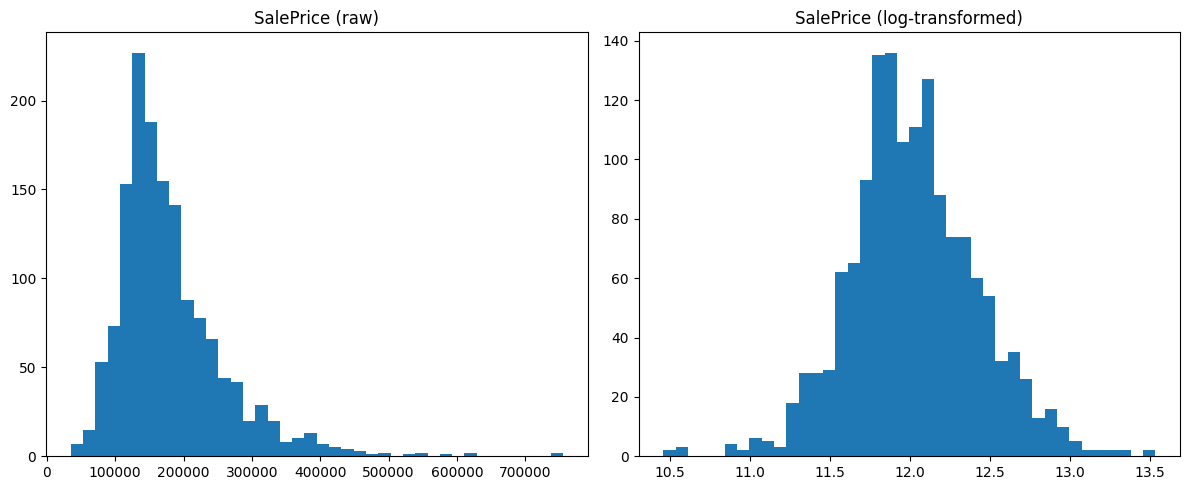

In [22]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].hist(df['SalePrice'], bins=40)
axes[0].set_title('SalePrice (raw)')

axes[1].hist(np.log1p(df['SalePrice']), bins=40)
axes[1].set_title('SalePrice (log-transformed)')

plt.tight_layout()
plt.show()

Raw SalePrice histogram shows a long right tail. Log-transformed version is visibly more symmetric/bell-shaped — supports applying log1p to the target before modeling.

## Step 4: Q-Q Plot — raw vs log-transformed

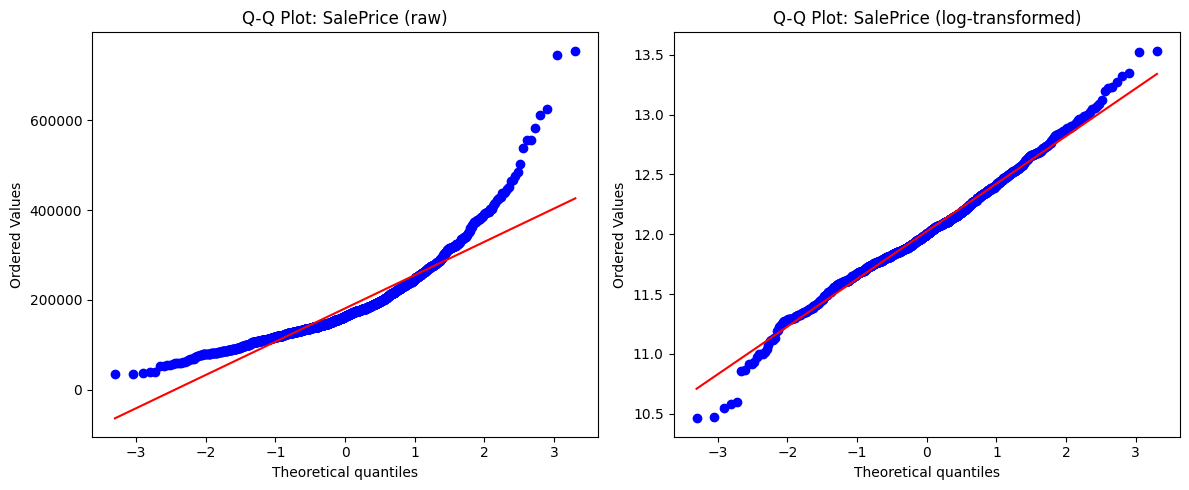

In [23]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(df['SalePrice'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: SalePrice (raw)')

stats.probplot(np.log1p(df['SalePrice']), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: SalePrice (log-transformed)')

plt.tight_layout()
plt.show()

Q-Q plot for raw SalePrice curves away from normal at the upper tail. Log-transformed version follows the diagonal much more closely — further confirms log-transform is the right move before fitting a linear model.

In [24]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

Added SalePrice_log = np.log1p(SalePrice) as the modeling target, based on skewness/Q-Q evidence above. Predictions from any model will need np.expm1() applied to convert back to actual dollar values before evaluation or submission.

# 4. Multivariate Analysis

# 3. Outliers Detection

In [25]:
correlations = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(correlations)

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
GarageYrBlt      0.508043
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

Ran a correlation check (df.corr()['SalePrice']) to rank features by relationship with price — used this to pick priority columns instead of guessing.


In [26]:
top_cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd']

df[top_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
GarageCars,1460.0,1.767123,0.747315,0.0,1.00,2.0,2.00,4.0
GarageArea,1460.0,472.980137,213.804841,0.0,334.50,480.0,576.00,1418.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0
FullBath,1460.0,1.565068,0.550916,0.0,1.00,2.0,2.00,3.0
TotRmsAbvGrd,1460.0,6.517808,1.625393,2.0,5.00,6.0,7.00,14.0


Ran .describe() on just those top columns (df[top_cols].describe().T) and compared each column's 75% value to its max.

Flagged TotalBsmtSF, GrLivArea, 1stFlrSF as priority candidates for scatterplotting against SalePrice

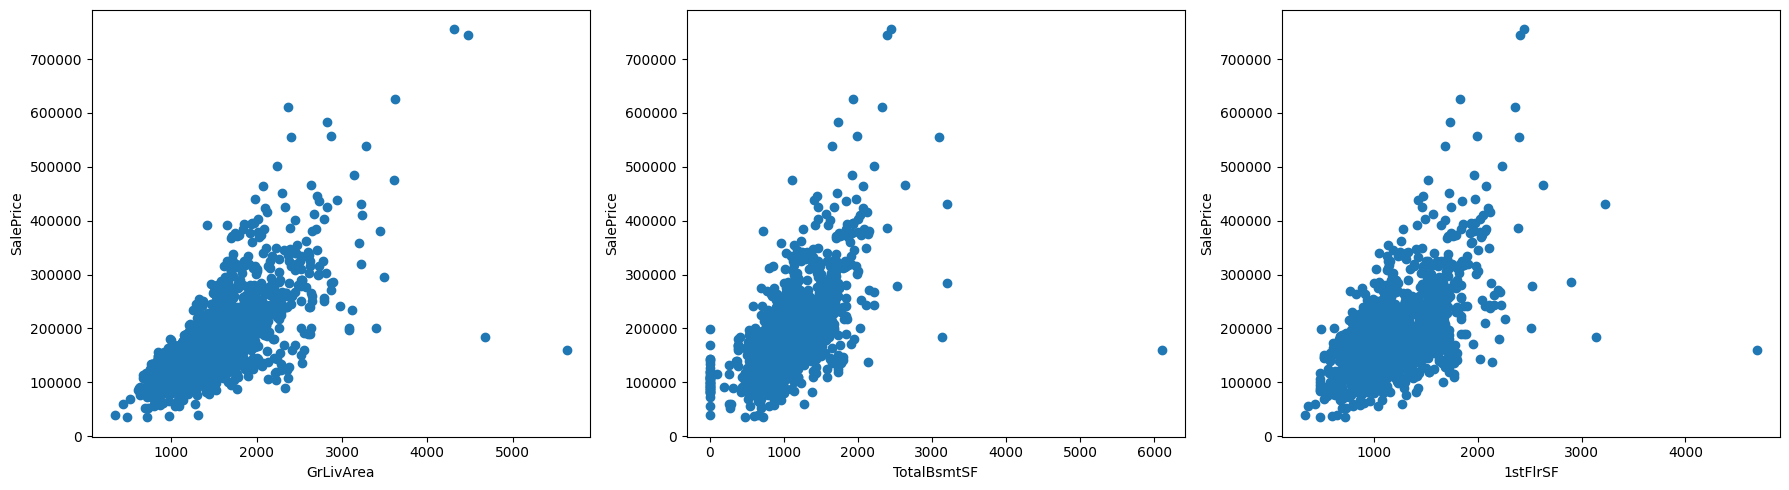

In [27]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].scatter(df['GrLivArea'], df['SalePrice'])
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')

axes[1].scatter(df['TotalBsmtSF'], df['SalePrice'])
axes[1].set_xlabel('TotalBsmtSF')
axes[1].set_xlabel('TotalBsmtSF')
axes[1].set_ylabel('SalePrice')

axes[2].scatter(df['1stFlrSF'], df['SalePrice'])
axes[2].set_xlabel('1stFlrSF')
axes[2].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

In [28]:
df[df['GrLivArea'] > 4000]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
523,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,Inside,...,None,None,None,0,10,2007,New,Partial,184750,12.126764
691,60,RL,104.0,21535,Pave,None,IR1,Lvl,AllPub,Corner,...,None,None,None,0,1,2007,WD,Normal,755000,13.534474
1182,60,RL,160.0,15623,Pave,None,IR1,Lvl,AllPub,Corner,...,Ex,MnPrv,None,0,7,2007,WD,Abnorml,745000,13.521141
1298,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,Corner,...,Gd,None,None,0,1,2008,New,Partial,160000,11.982935


Found 2 houses (GrLivArea > 4000 sqft) with unusually low SalePrice relative to their size. Both had SaleCondition = "Partial" (incomplete new construction at time of sale), explaining the broken size-to-price trend. Dropped rows 523 and 1298 as they don't represent normal market behavior.

In [29]:
df = df.drop(index=[523, 1298])
df = df.reset_index(drop=True)

In [30]:
df.shape

(1458, 81)